# Geomagnetic & Solar Indices — Event Plots

Generates a multi-panel figure (**Dst, Kp, Ap, F10.7, SSN**) for a storm/event window.

The plotting logic is written **once**, as a reusable function. Each event
(a contiguous run of days you want to combine into one figure) is just a
block of data plus a single function call — so adding a new event later
(e.g. two more days) means adding a new data block + call, not touching
the plotting code itself. Each event produces its own output PNG.


In [1]:
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Import publication styles and paths from your config
from src.configs.config import (
    GEOMAGNETIC_INDICES_DIR,
    PLOT_LABEL_FONTSIZE,
    PLOT_LABEL_FONTWEIGHT,
    PLOT_TICK_FONTSIZE,
    PLOT_TICK_FONTWEIGHT,
    PLOT_LEGEND_FONTSIZE,
    PLOT_LEGEND_FONTWEIGHT,
    PLOT_GRID_ALPHA,
    PLOT_DPI,
)

# Ensure the targeted metric indices directory exists before saving files
GEOMAGNETIC_INDICES_DIR.mkdir(parents=True, exist_ok=True)


### Helpers
Time-axis builders and the shared styling used across the loss / prediction /
delay plots elsewhere in this project (bold 13pt axis labels, bold 11pt
ticks, bold 11pt legend).


In [2]:
def hourly_times(start_date, n):
    """n hourly timestamps starting at start_date (used for Dst)."""
    return [start_date + timedelta(hours=i) for i in range(n)]


def three_hourly_times(start_date, n):
    """n 3-hourly timestamps starting at start_date (used for Kp, Ap)."""
    return [start_date + timedelta(hours=3 * i) for i in range(n)]


def daily_times(start_date, n_days):
    """One timestamp per day, placed at local noon (used for F10.7, SSN)."""
    return [start_date + timedelta(hours=24 * i + 12) for i in range(n_days)]


def _style_axis(ax, ylabel):
    ax.set_ylabel(ylabel, fontsize=PLOT_LABEL_FONTSIZE, fontweight=PLOT_LABEL_FONTWEIGHT)
    ax.grid(alpha=PLOT_GRID_ALPHA)
    ax.tick_params(axis="both", labelsize=PLOT_TICK_FONTSIZE)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontweight(PLOT_TICK_FONTWEIGHT)


def _panel_label(ax, label):
    ax.text(-0.06, 1.05, label, transform=ax.transAxes,
            fontsize=PLOT_LABEL_FONTSIZE, fontweight=PLOT_LABEL_FONTWEIGHT,
            va="bottom", ha="right")


### Reusable event-plotting function
```text
Call once per event (a contiguous block of days). Handles any number of
days automatically — the number of days is inferred from len(dst)/24.

Inputs (all UT):
  event_label : str   e.g. "9-10 May 2024"  (used on the x-axis label)
  start_date  : datetime  first day, 00:00 UT
  dst         : list[float]  hourly values,        len == 24 * n_days
  kp          : list[float]  3-hourly values,       len ==  8 * n_days
  ap          : list[float]  3-hourly values,        len ==  8 * n_days
  f107        : list[float]  one value per day,     len ==  n_days
  ssn         : list[float]  one value per day,     len ==  n_days
  filename    : str   output PNG name, saved under GEOMAGNETIC_INDICES_DIR

Returns: the saved file path.
```

In [3]:
def plot_geomagnetic_event(event_label, start_date, dst, kp, ap, f107, ssn, filename):
    n_days = len(dst) // 24
    assert len(dst) == 24 * n_days, "dst must have 24 hourly values per day"
    assert len(kp) == 8 * n_days, "kp must have 8 three-hourly values per day"
    assert len(ap) == 8 * n_days, "ap must have 8 three-hourly values per day"
    assert len(f107) == n_days, "f107 must have exactly one value per day"
    assert len(ssn) == n_days, "ssn must have exactly one value per day"

    dst_times  = hourly_times(start_date, 24 * n_days)
    kpap_times = three_hourly_times(start_date, 8 * n_days)
    daily_pts  = daily_times(start_date, n_days)

    fig, axes = plt.subplots(5, 1, figsize=(12, 14), sharex=True)

    axes[0].plot(dst_times, dst, color='#1f77b4', marker='o', markersize=3)
    axes[0].axhline(0, color='gray', linewidth=0.7, linestyle='--')
    _style_axis(axes[0], "Dst (nT)")

    axes[1].step(kpap_times, kp, where='post', color='#ff7f0e', marker='o', markersize=4)
    axes[1].axhline(9, color='red', linewidth=0.7, linestyle=':')
    _style_axis(axes[1], "Kp index")

    axes[2].step(kpap_times, ap, where='post', color='#2ca02c', marker='o', markersize=4)
    _style_axis(axes[2], "Ap index")

    axes[3].plot(daily_pts, f107, color='#d62728', marker='o', markersize=5, linestyle='-')
    _style_axis(axes[3], "F10.7 (sfu)")

    axes[4].plot(daily_pts, ssn, color='#9467bd', marker='o', markersize=5, linestyle='-')
    _style_axis(axes[4], "SSN")

    # Day-boundary guide lines for multi-day events
    for d in range(1, n_days):
        boundary = start_date + timedelta(hours=24 * d)
        for ax in axes:
            ax.axvline(boundary, color='black', linewidth=0.8, linestyle='--', alpha=0.6)

    # 6-hour ticks across the whole window, ending at the last minute of
    # the final day (23:59)
    tick_hours = list(range(0, 24 * n_days, 6))
    ticks = [start_date + timedelta(hours=h) for h in tick_hours]
    labels = [f"{h % 24:02d}:00" for h in tick_hours]
    ticks.append(start_date + timedelta(hours=24 * n_days - 1, minutes=59))
    labels.append("23:59")

    axes[-1].set_xticks(ticks)
    axes[-1].set_xticklabels(labels, rotation=45,
                              fontsize=PLOT_TICK_FONTSIZE, fontweight=PLOT_TICK_FONTWEIGHT)
    axes[-1].set_xlabel(f"Time (UT) — {event_label}",
                         fontsize=PLOT_LABEL_FONTSIZE, fontweight=PLOT_LABEL_FONTWEIGHT)
    axes[-1].set_xlim(start_date, start_date + timedelta(hours=24 * n_days))

    for ax, label in zip(axes, ['a', 'b', 'c', 'd', 'e']):
        _panel_label(ax, label)

    fig.tight_layout()

    save_path = GEOMAGNETIC_INDICES_DIR / filename
    fig.savefig(save_path, dpi=PLOT_DPI, bbox_inches="tight")
    plt.show()

    print(f"Saved: {save_path}")
    return save_path


---
## Event 1 — 9–10 May 2024

Dst, Kp, and Ap below are the real values used previously. **F10.7 and SSN
are placeholders (`None`)** — I don't have those values, so plug in the
actual daily F10.7 (sfu) and Sunspot Number for 9 and 10 May 2024
(e.g. from https://www.swpc.noaa.gov/ or the GFZ Potsdam indices service)
before running this cell.


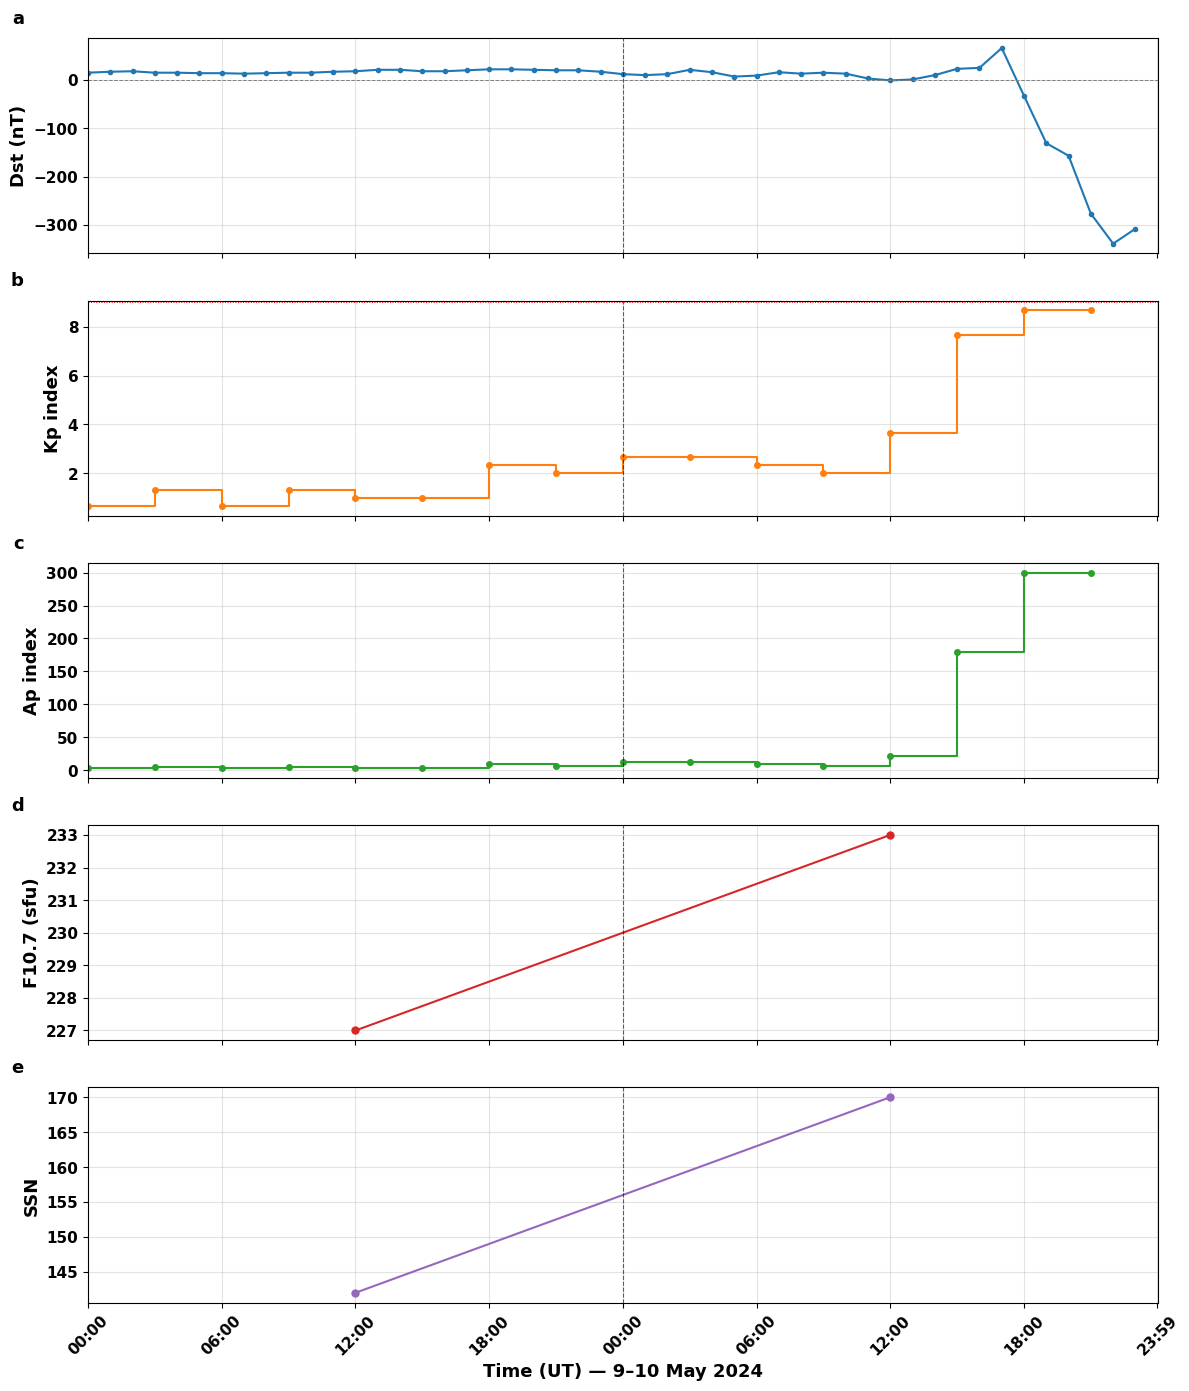

Saved: D:\Projects\ionospheric-tec-forecasting\generated_plots\geomagnetic_indices_plots\geomag_9_10may2024.png


WindowsPath('D:/Projects/ionospheric-tec-forecasting/generated_plots/geomagnetic_indices_plots/geomag_9_10may2024.png')

In [4]:
event1_label = "9–10 May 2024"
event1_start = datetime(2024, 5, 9)

dst_event1 = (
    [15, 17, 18, 15, 15, 14, 14, 13, 14, 15, 15, 17, 18, 21, 21, 18, 18, 20, 22, 22, 21, 20, 20, 17]   # 9 May
    + [12, 10, 12, 21, 16, 7, 9, 16, 13, 15, 13, 3, -1, 1, 10, 23, 25, 66, -33, -131, -157, -277, -339, -308]  # 10 May
)

kp_event1 = (
    [0.667, 1.333, 0.667, 1.333, 1.000, 1.000, 2.333, 2.000]   # 9 May
    + [2.667, 2.667, 2.333, 2.000, 3.667, 7.667, 8.667, 8.667]  # 10 May
)

ap_event1 = (
    [3, 5, 3, 5, 4, 4, 9, 7]        # 9 May
    + [12, 12, 9, 7, 22, 179, 300, 300]  # 10 May
)

f107_event1 = [227, 233]

ssn_event1 = [142, 170]

plot_geomagnetic_event(
    event_label=event1_label,
    start_date=event1_start,
    dst=dst_event1,
    kp=kp_event1,
    ap=ap_event1,
    f107=f107_event1,
    ssn=ssn_event1,
    filename="geomag_9_10may2024.png",
)


---
## Adding a future event

When you have data for two more days, just add a new data block + call —
no changes needed to `plot_geomagnetic_event` itself. Copy the template
below, fill in the values, and run it; it will write its **own** PNG.

```python
event2_label = "<label, e.g. 11-12 June 2024>"
event2_start = datetime(YYYY, M, D)

dst_event2  = [...]   # 24 hourly values per day
kp_event2   = [...]   # 8 three-hourly values per day
ap_event2   = [...]   # 8 three-hourly values per day
f107_event2 = [...]   # 1 value per day
ssn_event2  = [...]   # 1 value per day

plot_geomagnetic_event(
    event_label=event2_label,
    start_date=event2_start,
    dst=dst_event2,
    kp=kp_event2,
    ap=ap_event2,
    f107=f107_event2,
    ssn=ssn_event2,
    filename="geomag_<new_event>.png",
)
```

---
## Event 2 — 22–23 May 2024

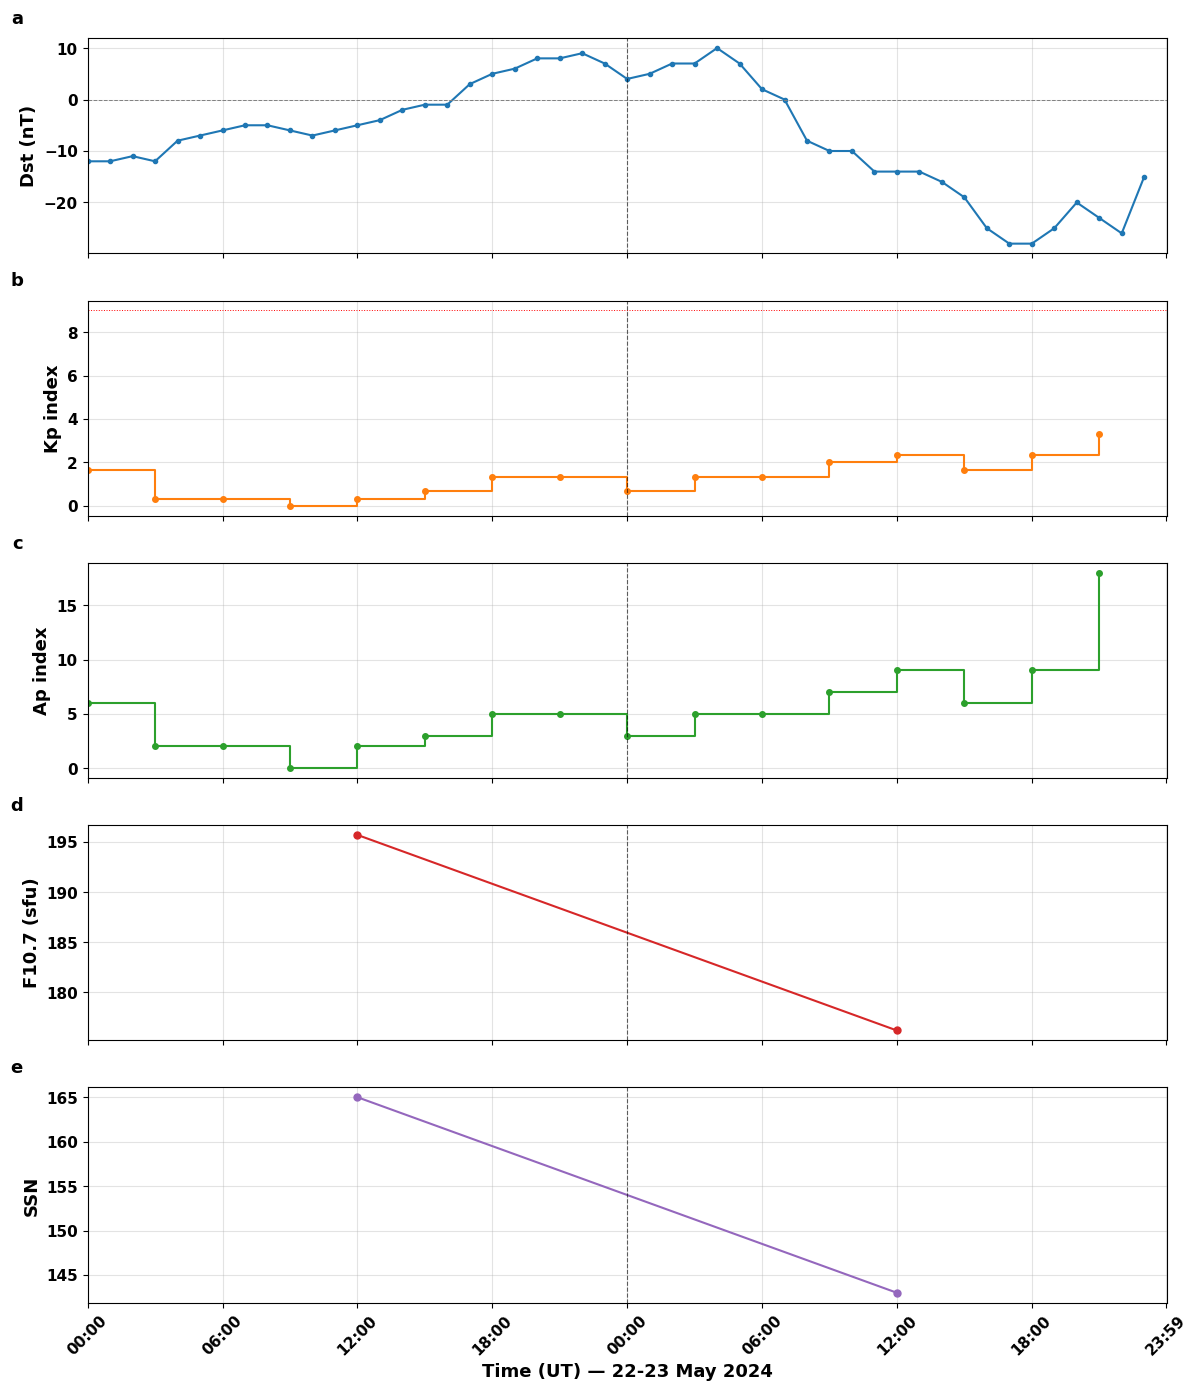

Saved: D:\Projects\ionospheric-tec-forecasting\generated_plots\geomagnetic_indices_plots\geomag_22_23may2024.png


WindowsPath('D:/Projects/ionospheric-tec-forecasting/generated_plots/geomagnetic_indices_plots/geomag_22_23may2024.png')

In [5]:
event2_label = "22-23 May 2024"
event2_start = datetime(2024, 5, 22)

dst_event2 = (
    [-12, -12, -11, -12, -8, -7, -6, -5, -5, -6, -7, -6, -5, -4, -2, -1, -1, 3, 5, 6, 8, 8, 9, 7]        # 22 May
    + [4, 5, 7, 7, 10, 7, 2, 0, -8, -10, -10, -14, -14, -14, -16, -19, -25, -28, -28, -25, -20, -23, -26, -15]  # 23 May
)

kp_event2 = (
    [1.667, 0.333, 0.333, 0.000, 0.333, 0.667, 1.333, 1.333]   # 22 May
    + [0.667, 1.333, 1.333, 2.000, 2.333, 1.667, 2.333, 3.333]  # 23 May
)

ap_event2 = (
    [6, 2, 2, 0, 2, 3, 5, 5]        # 22 May
    + [3, 5, 5, 7, 9, 6, 9, 18]     # 23 May
)

f107_event2 = [195.7, 176.2]
ssn_event2 = [165, 143]

plot_geomagnetic_event(
    event_label=event2_label,
    start_date=event2_start,
    dst=dst_event2,
    kp=kp_event2,
    ap=ap_event2,
    f107=f107_event2,
    ssn=ssn_event2,
    filename="geomag_22_23may2024.png",
)
